#### NCSU GIS 714: Geospatial Computation and Simulations

## Spatio-temporal data handling and visualization in GRASS GIS

Additional Resources:
* [GRASS GIS Overview and Manual](https://grass.osgeo.org/grass-stable/manuals/index.html)
* [GRASS book](http://www.grassbook.org/)

## Climate Data Analysis

### Start GRASS GIS

In [103]:
import subprocess
import sys
import json
import matplotlib.pyplot as plt
from datetime import datetime

# Ask GRASS GIS where its Python packages are.
grass_call = "grass84"
shell_setting = True

sys.path.append(
    subprocess.check_output([grass_call, "--config", "python_path"], text=True, shell=shell_setting).strip()
)

# Import GRASS packages
import grass.script as gs
import grass.jupyter as gj

# Start GRASS Session
gj.init("C:\\Users\\Nietolaj\\OneDrive - Mondigroup\\NC State\\Spring 2026\\Geospatial Computation and Simulation\\GIS714-assignments-main\\GIS714-assignments-main\\data\\", "ERA5", "TMax")

Set computational region to the extent of South Africa.

In [104]:
gs.run_command("g.region", n="-22.12", s="-34.84", e="32.95", w="16.25")

List all available raster maps. 

In [ ]:
gs.run_command("g.remove", type="raster", pattern="*", flags="f")
print(gs.read_command("g.list", type="raster"))

### Space-Time Datasets

In [107]:
#gs.run_command("t.remove", inputs="TYear,TMax,TMaxBC,Ratio", flags="f")
print(gs.read_command("t.list", type="strds"))

Import rasters as a netcdf.
Skip if rasters already imported.

In [108]:
gs.run_command(
    "r.in.gdal", 
    input = r"C:\Users\Nietolaj\OneDrive - Mondigroup\NC State\Spring 2026\Geospatial Computation and Simulation\Project\R Scripts\TMAX_BC.tif",
    output = "TMax_BC",
    overwrite=True
)

In [109]:
gs.run_command(
    "r.in.gdal", 
    input = r"C:\Users\Nietolaj\OneDrive - Mondigroup\NC State\Spring 2026\Geospatial Computation and Simulation\Project\R Scripts\TMAX_OS.tif",
    output = "TMax_OS",
    overwrite=True
)

Create an empty temporal dataset.

In [110]:
gs.run_command(
    "t.create",
    output="TMax",
    type="strds",
    temporaltype="absolute",
    title="Monthly Mean Maximum Temperature",
    description="ERA5 Maximum Temperatures from 2017 to 2025",
)

In [111]:
gs.run_command(
    "t.create",
    output="TMaxBC",
    type="strds",
    temporaltype="absolute",
    title="Monthly Mean Maximum Temperature",
    description="Bias-Corrected Maximum Temperatures from 2017 to 2025",
)

Get a list of names of all rasters to be added to the space-time dataset.

In [112]:
import re
names = gs.read_command("g.list", type="raster", pattern="TMax_OS.*", separator=",").strip()
names = names.split(",")
names = sorted(names, key=lambda x: int(re.search(r'\d+$', x).group()))
names = ",".join(names)
print(names)

TMax_OS.1,TMax_OS.2,TMax_OS.3,TMax_OS.4,TMax_OS.5,TMax_OS.6,TMax_OS.7,TMax_OS.8,TMax_OS.9,TMax_OS.10,TMax_OS.11,TMax_OS.12,TMax_OS.13,TMax_OS.14,TMax_OS.15,TMax_OS.16,TMax_OS.17,TMax_OS.18,TMax_OS.19,TMax_OS.20,TMax_OS.21,TMax_OS.22,TMax_OS.23,TMax_OS.24,TMax_OS.25,TMax_OS.26,TMax_OS.27,TMax_OS.28,TMax_OS.29,TMax_OS.30,TMax_OS.31,TMax_OS.32,TMax_OS.33,TMax_OS.34,TMax_OS.35,TMax_OS.36,TMax_OS.37,TMax_OS.38,TMax_OS.39,TMax_OS.40,TMax_OS.41,TMax_OS.42,TMax_OS.43,TMax_OS.44,TMax_OS.45,TMax_OS.46,TMax_OS.47,TMax_OS.48,TMax_OS.49,TMax_OS.50,TMax_OS.51,TMax_OS.52,TMax_OS.53,TMax_OS.54,TMax_OS.55,TMax_OS.56,TMax_OS.57,TMax_OS.58,TMax_OS.59,TMax_OS.60,TMax_OS.61,TMax_OS.62,TMax_OS.63,TMax_OS.64,TMax_OS.65,TMax_OS.66,TMax_OS.67,TMax_OS.68,TMax_OS.69,TMax_OS.70,TMax_OS.71,TMax_OS.72,TMax_OS.73,TMax_OS.74,TMax_OS.75,TMax_OS.76,TMax_OS.77,TMax_OS.78,TMax_OS.79,TMax_OS.80,TMax_OS.81,TMax_OS.82,TMax_OS.83,TMax_OS.84,TMax_OS.85,TMax_OS.86,TMax_OS.87,TMax_OS.88,TMax_OS.89,TMax_OS.90,TMax_OS.91,TMax_OS.

Register raster maps into  empty space-time dataset.

In [113]:
# Register the rasters to the space time dataset.
gs.run_command(
        "t.register",
        input="TMax",
        maps=names,
        start="2017-01-01",
        increment="1 month"
    )

#Set the computational region to a current raster.
#gs.run_command("g.region", raster="TMax_OS.1")

print(gs.read_command("t.info", input="TMax", flags="g"))

id=TMax@TMax
name=TMax
mapset=TMax
creator=NietoLaJ
temporal_type=absolute
creation_time='2026-03-08 16:07:33.633224'
modification_time='2026-03-08 16:07:50.645939'
semantic_type=mean
start_time='2017-01-01 00:00:00'
end_time='2025-12-01 00:00:00'
granularity='1 month'
map_time=point
north=-21.875
south=-35.125
east=33.125
west=15.875
top=0.0
bottom=0.0
raster_register=raster_map_register_575f02d15d8f4c488dee9da92ebafbda
nsres_min=0.25
nsres_max=0.25
ewres_min=0.25
ewres_max=0.25
min_min=6.987459
min_max=17.7971
max_min=25.891157
max_max=38.859711
aggregation_type=None
number_of_semantic_labels=0
semantic_labels=None
number_of_maps=108



Get a list of names of all rasters to be added to the space-time dataset.

In [114]:
import re
names = gs.read_command("g.list", type="raster", pattern="TMax_BC.*", separator=",").strip()
names = names.split(",")
names = sorted(names, key=lambda x: int(re.search(r'\d+$', x).group()))
names = ",".join(names)
print(names)

TMax_BC.1,TMax_BC.2,TMax_BC.3,TMax_BC.4,TMax_BC.5,TMax_BC.6,TMax_BC.7,TMax_BC.8,TMax_BC.9,TMax_BC.10,TMax_BC.11,TMax_BC.12,TMax_BC.13,TMax_BC.14,TMax_BC.15,TMax_BC.16,TMax_BC.17,TMax_BC.18,TMax_BC.19,TMax_BC.20,TMax_BC.21,TMax_BC.22,TMax_BC.23,TMax_BC.24,TMax_BC.25,TMax_BC.26,TMax_BC.27,TMax_BC.28,TMax_BC.29,TMax_BC.30,TMax_BC.31,TMax_BC.32,TMax_BC.33,TMax_BC.34,TMax_BC.35,TMax_BC.36,TMax_BC.37,TMax_BC.38,TMax_BC.39,TMax_BC.40,TMax_BC.41,TMax_BC.42,TMax_BC.43,TMax_BC.44,TMax_BC.45,TMax_BC.46,TMax_BC.47,TMax_BC.48,TMax_BC.49,TMax_BC.50,TMax_BC.51,TMax_BC.52,TMax_BC.53,TMax_BC.54,TMax_BC.55,TMax_BC.56,TMax_BC.57,TMax_BC.58,TMax_BC.59,TMax_BC.60,TMax_BC.61,TMax_BC.62,TMax_BC.63,TMax_BC.64,TMax_BC.65,TMax_BC.66,TMax_BC.67,TMax_BC.68,TMax_BC.69,TMax_BC.70,TMax_BC.71,TMax_BC.72,TMax_BC.73,TMax_BC.74,TMax_BC.75,TMax_BC.76,TMax_BC.77,TMax_BC.78,TMax_BC.79,TMax_BC.80,TMax_BC.81,TMax_BC.82,TMax_BC.83,TMax_BC.84,TMax_BC.85,TMax_BC.86,TMax_BC.87,TMax_BC.88,TMax_BC.89,TMax_BC.90,TMax_BC.91,TMax_BC.

Register raster maps into  empty space-time dataset.

In [115]:
# Register the rasters to the space time dataset.
gs.run_command(
        "t.register",
        input="TMaxBC",
        maps=names,
        start="2017-01-01",
        increment="1 month"
    )

#Set the computational region to a current raster.
#gs.run_command("g.region", raster="TMax_BC.1")

print(gs.read_command("t.info", input="TMaxBC", flags="g"))

id=TMaxBC@TMax
name=TMaxBC
mapset=TMax
creator=NietoLaJ
temporal_type=absolute
creation_time='2026-03-08 16:07:35.152078'
modification_time='2026-03-08 16:08:07.582685'
semantic_type=mean
start_time='2017-01-01 00:00:00'
end_time='2025-12-01 00:00:00'
granularity='1 month'
map_time=point
north=-21.875
south=-35.125
east=33.125
west=15.875
top=0.0
bottom=0.0
raster_register=raster_map_register_8dda06e70ccd44b9936c3df058165362
nsres_min=0.25
nsres_max=0.25
ewres_min=0.25
ewres_max=0.25
min_min=6.650567
min_max=17.927233
max_min=26.370989
max_max=39.899841
aggregation_type=None
number_of_semantic_labels=0
semantic_labels=None
number_of_maps=108



In [124]:
#Doing map algebra on the two spacetime datasets.
gs.run_command("t.rast.algebra",
               expression="Difference=TMaxBC@TMax-TMax@TMax",
               basename="Difference")

In [125]:
print(gs.read_command("t.list", type="strds"))

Difference@TMax
TMax@TMax
TMaxBC@TMax
TYear@TMax



### Temporal Aggregation

Aggregating to a yearly level.

In [126]:
gs.run_command('t.rast.aggregate', input='Difference@TMax',
                output='TYear', base='TYear',
                granularity="1 years", method='average',
                where="start_time >= '2017-01-01' and start_time <= '2026-01-01'")

In [128]:
gs.run_command("t.rast.colors", input="TYear", color="viridis")

tyear_map = gj.TimeSeriesMap(use_region=True)
tyear_map.add_raster_series("TYear", fill_gaps=True)
tyear_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="black")
tyear_map.d_legend(color="black", at=(10, 90, 0, 2))
tyear_map.save(filename = "tmax_diffs.gif", font=r"C:\Windows\Fonts\arial.ttf", text_color="black", text_size=18, duration=800)
tyear_map.show()

Performing some basic time-based statistics.

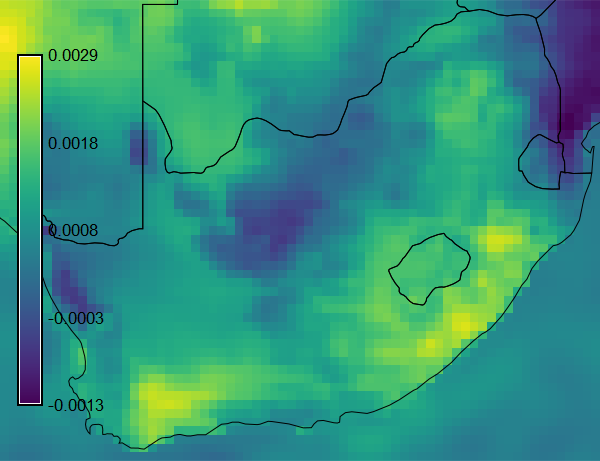

In [17]:
#Try different methods (sum, average, stddev, maximum, minimum, slope)
gs.run_command(
    "t.rast.series",
    input="TMax",
    output="TMax_Stat",
    method="slope"
)

gs.run_command("r.colors", map="TMax_Stat", color="viridis")

stat_map = gj.Map()
stat_map.d_rast(map="TMax_Stat")
stat_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="black")
stat_map.d_legend(raster="TMax_Stat")
stat_map.show()

Computing some other statistics.

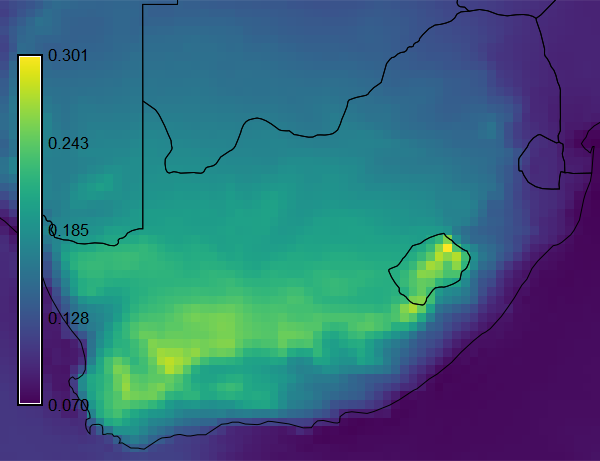

In [21]:
gs.run_command(
    "t.rast.series",
    input="TMax",
    output="TMax_Mean",
    method="average"
)

gs.run_command(
    "t.rast.series",
    input="TMax",
    output="TMax_SD",
    method="stddev"
)

#Coefficient of Variation.
#Lower CV, more consistent values.
gs.run_command("r.mapcalc", expression="TMax_CV = TMax_SD / TMax_Mean")
gs.run_command("r.colors", map="TMax_CV", color="viridis")

stat_map = gj.Map()
stat_map.d_rast(map="TMax_CV")
stat_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="black")
stat_map.d_legend(raster="TMax_CV")
stat_map.show()

Checking how many years the temperature of each pixel was above a threshold. 

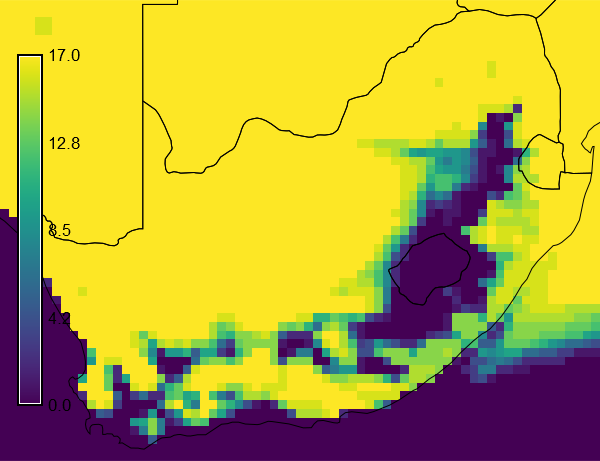

In [24]:
#Counting how many years' temperatures were above a threshold.
gs.run_command(
    "t.rast.mapcalc",
    input="TYear",    
    output="TDry",    
    expression="if(TYear > 22, 1, 0)",
    basename = "DryYears"
)

gs.run_command(
    "t.rast.series",
    input="TDry",
    output="TDry_Sum",
    method="sum"
)

gs.run_command("r.colors", map="TDry_Sum", color="viridis")

stat_map = gj.Map()
stat_map.d_rast(map="TDry_Sum")
stat_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="black")
stat_map.d_legend(raster="TDry_Sum")
stat_map.show()

Counting the number of months above a threshold rainfall. This takes a few minutes.

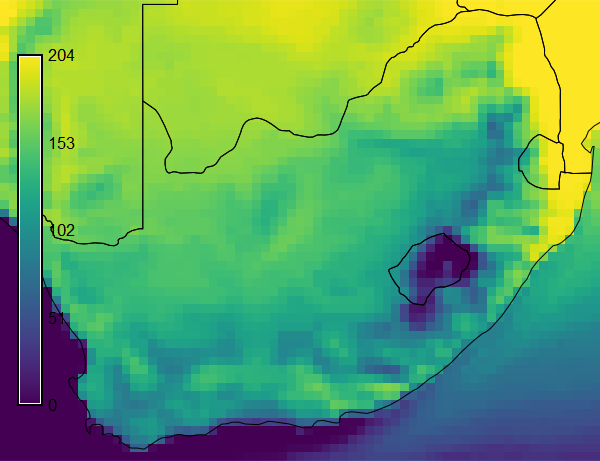

In [25]:
#Counting how many months' rainfall was under a threshold.
gs.run_command(
    "t.rast.mapcalc",
    input="TMax",    
    output="TDry",    
    expression="if(TMax > 22, 1, 0)",
    basename = "DryMonths"
)

#Summing
gs.run_command(
    "t.rast.series",
    input="TDry",
    output="TDry_Sum",
    method="sum"
)

gs.run_command("r.colors", map="TDry_Sum", color="viridis")

stat_map = gj.Map()
stat_map.d_rast(map="TDry_Sum")
stat_map.d_vect(map="world_countries@PERMANENT", fill_color="none", color="black")
stat_map.d_legend(raster="TDry_Sum")
stat_map.show()

In [8]:
gs.run_command("t.remove", inputs="PYear,PSum", flags="f")

print(gs.read_command("t.list", type="strds"))

PSum@PSum

